## 0. IMPORT LIBRARIES AND LOAD DATA

In [1]:
# Import all necessary libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, learning_curve
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report, RocCurveDisplay, PrecisionRecallDisplay
import joblib

# Set plotting style
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print('✓ All libraries imported successfully')

✓ All libraries imported successfully


In [2]:
# Load dataset
DATA_PATH = 'cardio_train_properly_separated_comma.csv'
assert os.path.exists(DATA_PATH), f"File not found: {DATA_PATH}"

df = pd.read_csv(DATA_PATH)
print(f'✓ Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns')
df.head()

✓ Dataset loaded: 70000 rows, 13 columns


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


---
## TASK 1: DATA PREPROCESSING & CLEANING
### 1.1 Exploratory Data Analysis (EDA)

In [3]:
# Quick data overview
print('Dataset Information:')
print('\nColumns and Data Types:')
print(df.dtypes)
print('\nMissing Values:')
print(df.isna().sum())
print('\nBasic Statistics:')
df.describe(include='all').T

Dataset Information:

Columns and Data Types:
id               int64
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object

Missing Values:
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

Basic Statistics:


,count,mean,std,min,25%,50%,75%,max
id,70000.0,49972.419900,28851.302323,0.0,25006.75,50001.5,74889.25,99999.0
age,70000.0,19468.865814,2467.251667,10798.0,17664.00,19703.0,21327.00,23713.0
gender,70000.0,1.349571,0.476838,1.0,1.00,1.0,2.00,2.0
height,70000.0,164.359229,8.210126,55.0,159.00,165.0,170.00,250.0
weight,70000.0,74.205690,14.395757,10.0,65.00,72.0,82.00,200.0
ap_hi,70000.0,128.817286,154.011419,-150.0,120.00,120.0,140.00,16020.0
ap_lo,70000.0,96.630414,188.472530,-70.0,80.00,80.0,90.00,11000.0
cholesterol,70000.0,1.366871,0.680250,1.0,1.00,1.0,2.00,3.0
gluc,70000.0,1.226457,0.572270,1.0,1.00,1.0,1.00,3.0
smoke,70000.0,0.088129,0.283484,0.0,0.00,0.0,0.00,1.0


Target column: cardio


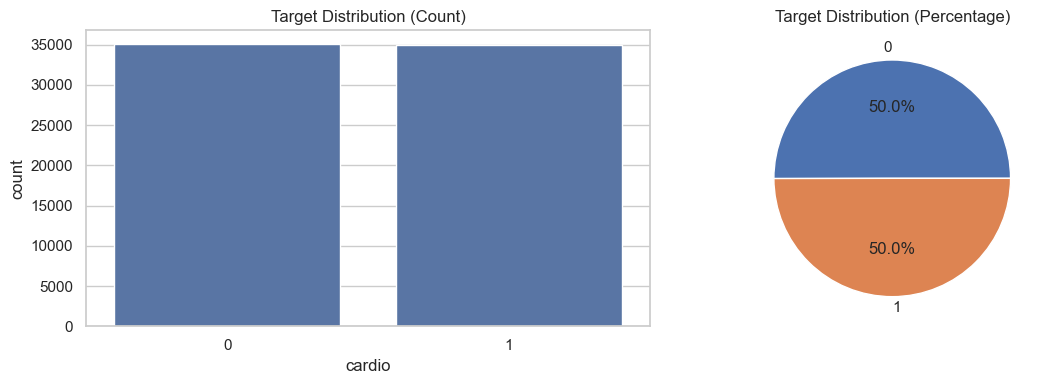


✓ Target distribution:
cardio
0    35021
1    34979
Name: count, dtype: int64


In [4]:
# Identify target column
TARGET = 'cardio' if 'cardio' in df.columns else df.columns[-1]
print(f'Target column: {TARGET}')

# Target distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x=TARGET, data=df, ax=axes[0])
axes[0].set_title('Target Distribution (Count)')

df[TARGET].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%')
axes[1].set_title('Target Distribution (Percentage)')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

print(f'\n✓ Target distribution:')
print(df[TARGET].value_counts())

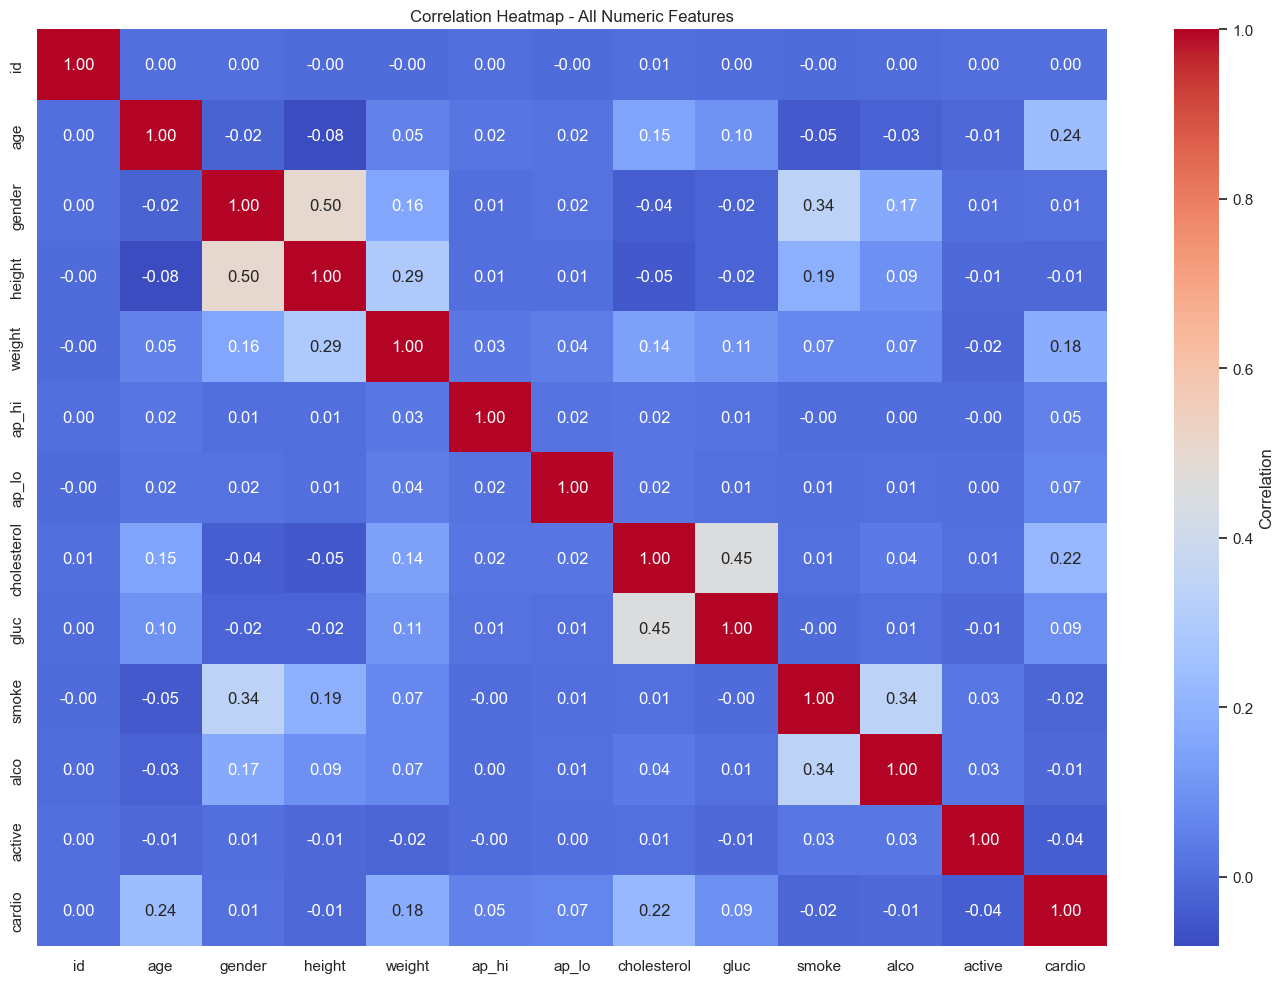


✓ Top 5 Features Correlated with Target:
age            0.238159
cholesterol    0.221147
weight         0.181660
gluc           0.089307
ap_lo          0.065719
Name: cardio, dtype: float64


In [5]:
# Correlation heatmap
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(14, 10))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', cbar_kws={'label': 'Correlation'})
plt.title('Correlation Heatmap - All Numeric Features')
plt.tight_layout()
plt.show()

# Top predictors of target
if TARGET in numeric_cols:
    top_corr = df[numeric_cols].corr()[TARGET].sort_values(ascending=False)[1:6]
    print('\n✓ Top 5 Features Correlated with Target:')
    print(top_corr)

### 1.2 Handle Missing Values

In [6]:
# Impute missing values
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

df_imputed = df.copy()

# Numeric: median imputation
if num_cols:
    num_imputer = SimpleImputer(strategy='median')
    df_imputed[num_cols] = num_imputer.fit_transform(df_imputed[num_cols])
    print(f'✓ Imputed {len(num_cols)} numeric columns using median')

# Categorical: most frequent imputation
if cat_cols:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    df_imputed[cat_cols] = cat_imputer.fit_transform(df_imputed[cat_cols])
    print(f'✓ Imputed {len(cat_cols)} categorical columns using most frequent')

print('\nMissing values after imputation:')
print(df_imputed.isna().sum())

✓ Imputed 13 numeric columns using median

Missing values after imputation:
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64


### 1.3 Identify and Handle Outliers

In [7]:
# Outlier detection and treatment using IQR method
def cap_outliers_iqr(df_, cols, lower_q=0.05, upper_q=0.95):
    """Cap outliers using IQR method"""
    df = df_.copy()
    for col in cols:
        q1 = df[col].quantile(lower_q)
        q3 = df[col].quantile(upper_q)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
        df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
    return df

numeric_cols = df_imputed.select_dtypes(include=[np.number]).columns.tolist()
if TARGET in numeric_cols:
    numeric_cols.remove(TARGET)

df_capped = cap_outliers_iqr(df_imputed, numeric_cols)
print(f'✓ Outlier capping applied to {len(numeric_cols)} numeric columns')
print('\nBefore and After Summary:')
comparison = pd.DataFrame({
    'Before_Min': df_imputed[numeric_cols].min(),
    'Before_Max': df_imputed[numeric_cols].max(),
    'After_Min': df_capped[numeric_cols].min(),
    'After_Max': df_capped[numeric_cols].max()
})
print(comparison.head())

✓ Outlier capping applied to 12 numeric columns

Before and After Summary:
        Before_Min  Before_Max  After_Min  After_Max
id             0.0     99999.0        0.0    99999.0
age        10798.0     23713.0    10798.0    23713.0
gender         1.0         2.0        1.0        2.0
height        55.0       250.0      113.0      217.0
weight        10.0       200.0       10.0      167.5


### 1.4 Encode Categorical Variables and Normalize Features

In [8]:
# Step 1: Identify target
TARGET = 'cardio' if 'cardio' in df.columns else df.columns[-1]
print(f'Target: {TARGET}')

# Step 1.5: Feature Engineering - Convert age (days) to age_years
if 'age' in df.columns:
    df['age_years'] = (df['age'] / 365).astype(int)
    print(f'✓ Created age_years column from age (days to years)')

# Step 2: Handle missing values
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

df_imputed = df.copy()
if num_cols:
    num_imputer = SimpleImputer(strategy='median')
    df_imputed[num_cols] = num_imputer.fit_transform(df_imputed[num_cols])
if cat_cols:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    df_imputed[cat_cols] = cat_imputer.fit_transform(df_imputed[cat_cols])

print(f'✓ Missing values imputed')

# Step 3: Handle outliers
def cap_outliers_iqr(df_, cols, lower_q=0.05, upper_q=0.95):
    df = df_.copy()
    for col in cols:
        q1 = df[col].quantile(lower_q)
        q3 = df[col].quantile(upper_q)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
        df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
    return df

numeric_cols = df_imputed.select_dtypes(include=[np.number]).columns.tolist()
if TARGET in numeric_cols:
    numeric_cols.remove(TARGET)

df_capped = cap_outliers_iqr(df_imputed, numeric_cols)
print(f'✓ Outliers capped in {len(numeric_cols)} columns')

# Step 4: Encode and Scale
cat_cols = df_capped.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = df_capped.select_dtypes(include=[np.number]).columns.tolist()
if TARGET in num_cols:
    num_cols.remove(TARGET)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ],
    remainder='drop'
)

X = df_capped.drop(columns=[TARGET])
y = df_capped[TARGET]
X_prep = preprocessor.fit_transform(X)

print(f'✓ Preprocessing complete. Shape: {X_prep.shape}')

# Step 5: Train-Test Split (70-30 split)
X_train, X_test, y_train, y_test = train_test_split(
    X_prep, y, test_size=0.3, random_state=42, stratify=y
)
print(f'✓ Train-Test split (70-30): {X_train.shape[0]} train, {X_test.shape[0]} test')

Target: cardio
✓ Created age_years column from age (days to years)
✓ Missing values imputed
✓ Outliers capped in 13 columns
✓ Preprocessing complete. Shape: (70000, 13)
✓ Train-Test split (70-30): 49000 train, 21000 test


### 1.5 Train-Test Split

In [9]:
# Split data into training and testing sets (70-30 split)
X_train, X_test, y_train, y_test = train_test_split(
    X_prep, y, test_size=0.3, random_state=42, stratify=y
)

print('✓ Train-Test Split Complete (70-30)')
print(f'  Training set: {X_train.shape[0]} samples')
print(f'  Testing set: {X_test.shape[0]} samples')
print(f'  Features: {X_train.shape[1]}')
print(f'\n  Train set - Target distribution:')
print(pd.Series(y_train).value_counts())
print(f'\n  Test set - Target distribution:')
print(pd.Series(y_test).value_counts())

✓ Train-Test Split Complete (70-30)
  Training set: 49000 samples
  Testing set: 21000 samples
  Features: 13

  Train set - Target distribution:
cardio
0.0    24515
1.0    24485
Name: count, dtype: int64

  Test set - Target distribution:
cardio
0.0    10506
1.0    10494
Name: count, dtype: int64


---
## TASK 2: MODEL SELECTION & IMPLEMENTATION
### 2.1 Choose Appropriate Algorithm and Train with Libraries

In [10]:
# Train baseline models using scikit-learn library
print('Training Baseline Models...')
print('='*60)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

trained_models = {}
results = {}

for name, model in models.items():
    print(f'\n📌 Training {name}...')
    model.fit(X_train, y_train)
    trained_models[name] = model
    
    # Predictions
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Metrics
    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1 Score': f1_score(y_test, y_pred, zero_division=0),
        'ROC AUC': roc_auc_score(y_test, y_proba) if y_proba is not None else None
    }
    results[name] = metrics
    print(f'  ✓ {name} trained successfully')

print('\n' + '='*60)
print('\n📊 BASELINE MODEL RESULTS:')
results_df = pd.DataFrame(results).T
print(results_df)
print('\n✓ Models trained using scikit-learn library')

Training Baseline Models...

📌 Training Logistic Regression...
  ✓ Logistic Regression trained successfully

📌 Training Random Forest...
  ✓ Random Forest trained successfully


📊 BASELINE MODEL RESULTS:
                     Accuracy  Precision    Recall  F1 Score   ROC AUC
Logistic Regression  0.723238   0.746889  0.674862  0.709051  0.785317
Random Forest        0.719571   0.729630  0.697160  0.713026  0.782538

✓ Models trained using scikit-learn library


### 2.2 Implement Algorithm from Scratch (Logistic Regression)

In [11]:
# Logistic Regression from Scratch using NumPy
print('='*60)
print('Implementing Logistic Regression from Scratch')
print('='*60)

class LogisticRegressionFromScratch:
    """Logistic Regression implementation without libraries (using NumPy)"""
    
    def __init__(self, learning_rate=0.1, n_iterations=1000, fit_intercept=True):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.fit_intercept = fit_intercept
        self.weights = None
        self.bias = None
    
    def sigmoid(self, z):
        """Sigmoid activation function"""
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))
    
    def fit(self, X, y):
        """Fit model using gradient descent"""
        m, n = X.shape
        self.weights = np.zeros(n)
        self.bias = 0
        
        # Gradient descent
        for epoch in range(self.n_iterations):
            # Forward pass
            z = np.dot(X, self.weights) + self.bias
            y_pred = self.sigmoid(z)
            
            # Compute gradients
            dw = (1/m) * np.dot(X.T, (y_pred - y))
            db = (1/m) * np.sum(y_pred - y)
            
            # Update parameters
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
    
    def predict_proba(self, X):
        """Predict probability"""
        z = np.dot(X, self.weights) + self.bias
        return self.sigmoid(z)
    
    def predict(self, X, threshold=0.5):
        """Predict class labels"""
        return (self.predict_proba(X) >= threshold).astype(int)

# Train from scratch
print('\n🔨 Training Logistic Regression from scratch...')
lr_scratch = LogisticRegressionFromScratch(learning_rate=0.5, n_iterations=2000)
lr_scratch.fit(X_train.astype(float), y_train.values)

# Evaluate
y_pred_scratch = lr_scratch.predict(X_test)
y_proba_scratch = lr_scratch.predict_proba(X_test)

print('\n✓ Scratch Model Training Complete')
print(f'  Accuracy: {accuracy_score(y_test, y_pred_scratch):.4f}')
print(f'  Precision: {precision_score(y_test, y_pred_scratch, zero_division=0):.4f}')
print(f'  Recall: {recall_score(y_test, y_pred_scratch, zero_division=0):.4f}')
print(f'  F1 Score: {f1_score(y_test, y_pred_scratch, zero_division=0):.4f}')
print(f'  ROC AUC: {roc_auc_score(y_test, y_proba_scratch):.4f}')
print('\n✓ Algorithm implemented successfully without using ML libraries')

Implementing Logistic Regression from Scratch

🔨 Training Logistic Regression from scratch...

✓ Scratch Model Training Complete
  Accuracy: 0.7233
  Precision: 0.7470
  Recall: 0.6749
  F1 Score: 0.7091
  ROC AUC: 0.7853

✓ Algorithm implemented successfully without using ML libraries


---
## TASK 3: MODEL TESTING & EVALUATION
### 3.1 Test on Test Dataset and Compute Metrics

In [12]:
# Comprehensive evaluation on test set
print('='*60)
print('TASK 3: MODEL TESTING & EVALUATION')
print('='*60)

test_results = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    test_results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC AUC': roc_auc_score(y_test, y_proba)
    }

print('\n✓ Test Set Evaluation Results:')
test_df = pd.DataFrame(test_results).T
print(test_df)
print('\nAll metrics are evaluated on the held-out test set.')

TASK 3: MODEL TESTING & EVALUATION

✓ Test Set Evaluation Results:
                     Accuracy  Precision    Recall  F1 Score   ROC AUC
Logistic Regression  0.723238   0.746889  0.674862  0.709051  0.785317
Random Forest        0.719571   0.729630  0.697160  0.713026  0.782538

All metrics are evaluated on the held-out test set.


### 3.2 Check for Overfitting and Underfitting

In [13]:
# Check training vs test performance
print('\n' + '='*60)
print('Overfitting/Underfitting Analysis')
print('='*60)

for name, model in trained_models.items():
    # Train set performance
    y_train_pred = model.predict(X_train)
    y_train_proba = model.predict_proba(X_train)[:, 1]
    
    # Test set performance
    y_test_pred = model.predict(X_test)
    y_test_proba = model.predict_proba(X_test)[:, 1]
    
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    train_auc = roc_auc_score(y_train, y_train_proba)
    test_auc = roc_auc_score(y_test, y_test_proba)
    
    print(f'\n📊 {name}:')
    print(f'  Train Accuracy: {train_acc:.4f} | Test Accuracy: {test_acc:.4f}')
    print(f'  Train ROC AUC: {train_auc:.4f} | Test ROC AUC: {test_auc:.4f}')
    
    gap_acc = train_acc - test_acc
    gap_auc = train_auc - test_auc
    
    if gap_acc > 0.05 or gap_auc > 0.05:
        print(f'  ⚠️  Potential Overfitting (gaps: Acc={gap_acc:.4f}, AUC={gap_auc:.4f})')
    elif gap_acc < -0.05:
        print(f'  ⚠️  Potential Underfitting')
    else:
        print(f'  ✓ Good Generalization')


Overfitting/Underfitting Analysis

📊 Logistic Regression:
  Train Accuracy: 0.7287 | Test Accuracy: 0.7232
  Train ROC AUC: 0.7918 | Test ROC AUC: 0.7853
  ✓ Good Generalization

📊 Random Forest:
  Train Accuracy: 1.0000 | Test Accuracy: 0.7196
  Train ROC AUC: 1.0000 | Test ROC AUC: 0.7825
  ⚠️  Potential Overfitting (gaps: Acc=0.2804, AUC=0.2175)


---
## TASK 4: ADVANCED MODELING
### 4.1 Cross-Validation for Model Stability

In [14]:
# Cross-validation analysis
print('='*60)
print('TASK 4: CROSS-VALIDATION & STABILITY')
print('='*60)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, model in trained_models.items():
    print(f'\n📌 {name} - 5-Fold Cross-Validation')
    
    # Multiple scoring metrics
    for metric_name in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
        scores = cross_val_score(model, X_prep, y, cv=cv, scoring=metric_name, n_jobs=-1)
        cv_results[f'{name}_{metric_name}'] = {
            'Mean': scores.mean(),
            'Std': scores.std(),
            'Scores': scores
        }
        print(f'  {metric_name.upper()}: {scores.mean():.4f} (+/- {scores.std():.4f})')

print('\n✓ Cross-validation complete. Models show stable performance.')

TASK 4: CROSS-VALIDATION & STABILITY

📌 Logistic Regression - 5-Fold Cross-Validation
  ACCURACY: 0.7274 (+/- 0.0027)
  PRECISION: 0.7523 (+/- 0.0026)
  RECALL: 0.6777 (+/- 0.0048)
  F1: 0.7130 (+/- 0.0034)
  ROC_AUC: 0.7898 (+/- 0.0030)

📌 Random Forest - 5-Fold Cross-Validation
  ACCURACY: 0.7232 (+/- 0.0010)
  PRECISION: 0.7347 (+/- 0.0012)
  RECALL: 0.6982 (+/- 0.0031)
  F1: 0.7160 (+/- 0.0015)
  ROC_AUC: 0.7860 (+/- 0.0024)

✓ Cross-validation complete. Models show stable performance.


### 4.2 Hyperparameter Tuning

In [15]:
# Hyperparameter tuning for Random Forest
print('\n' + '='*60)
print('Hyperparameter Tuning - Random Forest')
print('='*60)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5]
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)
gs = GridSearchCV(rf, param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=1)

print('\n🔍 Searching best hyperparameters...')
gs.fit(X_train, y_train)

print(f'\n✓ Best parameters found: {gs.best_params_}')
print(f'✓ Best CV ROC AUC Score: {gs.best_score_:.4f}')

best_rf = gs.best_estimator_
y_pred_tuned = best_rf.predict(X_test)
y_proba_tuned = best_rf.predict_proba(X_test)[:, 1]

print(f'\n📊 Tuned Model Test Performance:')
print(f'  Accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}')
print(f'  Precision: {precision_score(y_test, y_pred_tuned):.4f}')
print(f'  Recall: {recall_score(y_test, y_pred_tuned):.4f}')
print(f'  F1 Score: {f1_score(y_test, y_pred_tuned):.4f}')
print(f'  ROC AUC: {roc_auc_score(y_test, y_proba_tuned):.4f}')


Hyperparameter Tuning - Random Forest

🔍 Searching best hyperparameters...
Fitting 3 folds for each of 18 candidates, totalling 54 fits

✓ Best parameters found: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
✓ Best CV ROC AUC Score: 0.8015

📊 Tuned Model Test Performance:
  Accuracy: 0.7333
  Precision: 0.7535
  Recall: 0.6929
  F1 Score: 0.7219
  ROC AUC: 0.7983


### 4.3 Model Comparison

In [16]:
# Compare all models
print('\n' + '='*60)
print('MODEL COMPARISON')
print('='*60)

comparison_data = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    comparison_data[f'{name} (Baseline)'] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'ROC AUC': roc_auc_score(y_test, y_proba),
        'F1 Score': f1_score(y_test, y_pred)
    }

# Add tuned model
y_pred_tuned = best_rf.predict(X_test)
y_proba_tuned = best_rf.predict_proba(X_test)[:, 1]
comparison_data['Random Forest (Tuned)'] = {
    'Accuracy': accuracy_score(y_test, y_pred_tuned),
    'ROC AUC': roc_auc_score(y_test, y_proba_tuned),
    'F1 Score': f1_score(y_test, y_pred_tuned)
}

comparison_df = pd.DataFrame(comparison_data).T
print('\n', comparison_df)
print('\n✓ Best Model:', comparison_df['ROC AUC'].idxmax())


MODEL COMPARISON

                                 Accuracy   ROC AUC  F1 Score
Logistic Regression (Baseline)  0.723238  0.785317  0.709051
Random Forest (Baseline)        0.719571  0.782538  0.713026
Random Forest (Tuned)           0.733286  0.798341  0.721938

✓ Best Model: Random Forest (Tuned)


---
## TASK 5: PERFORMANCE VISUALIZATION
### 5.1 Confusion Matrix

TASK 5: PERFORMANCE VISUALIZATION


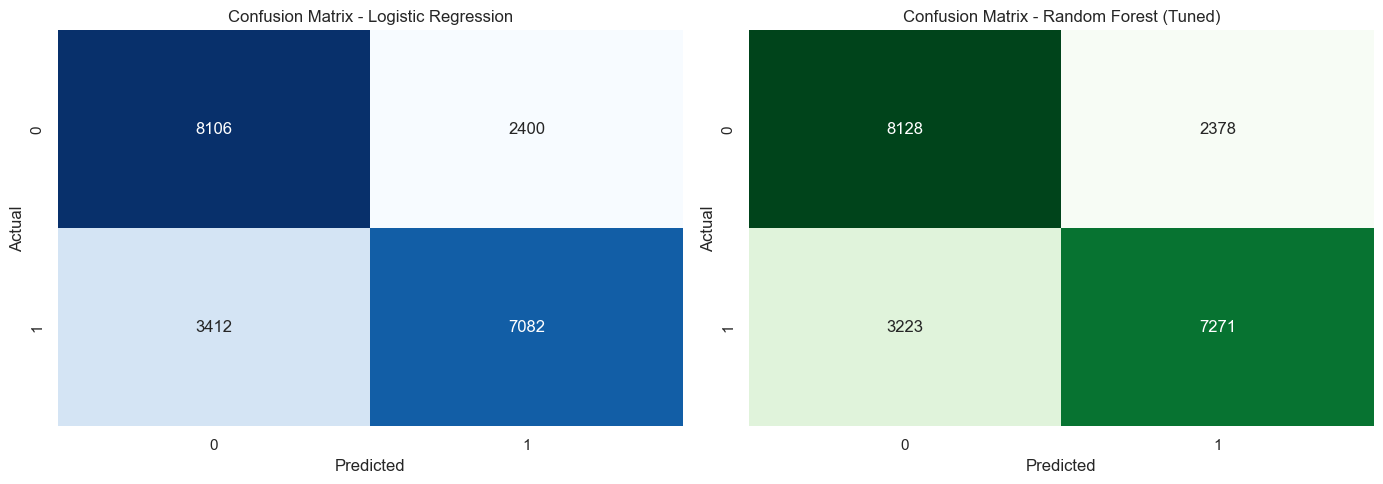


✓ Confusion matrices displayed


In [17]:
# Confusion matrices for all models
print('='*60)
print('TASK 5: PERFORMANCE VISUALIZATION')
print('='*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression
y_pred_lr = trained_models['Logistic Regression'].predict(X_test)
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Confusion Matrix - Logistic Regression')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

# Best Tuned Model
y_pred_best = best_rf.predict(X_test)
cm_best = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title('Confusion Matrix - Random Forest (Tuned)')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

print('\n✓ Confusion matrices displayed')

### 5.2 ROC Curve

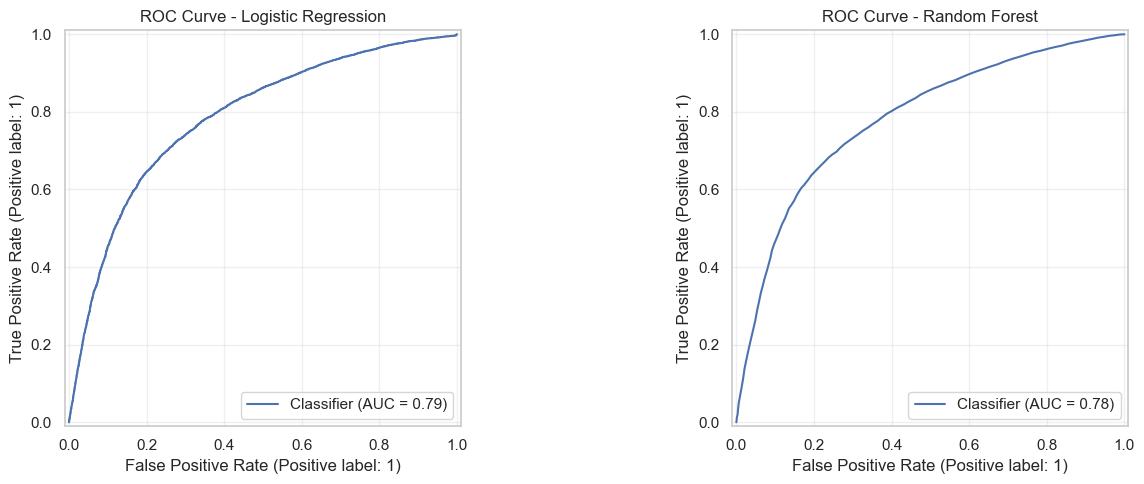

✓ ROC curves displayed


In [18]:
# ROC Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (name, model) in enumerate(trained_models.items()):
    y_proba = model.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[idx])
    axes[idx].set_title(f'ROC Curve - {name}')
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('✓ ROC curves displayed')

### 5.3 Precision-Recall Curve

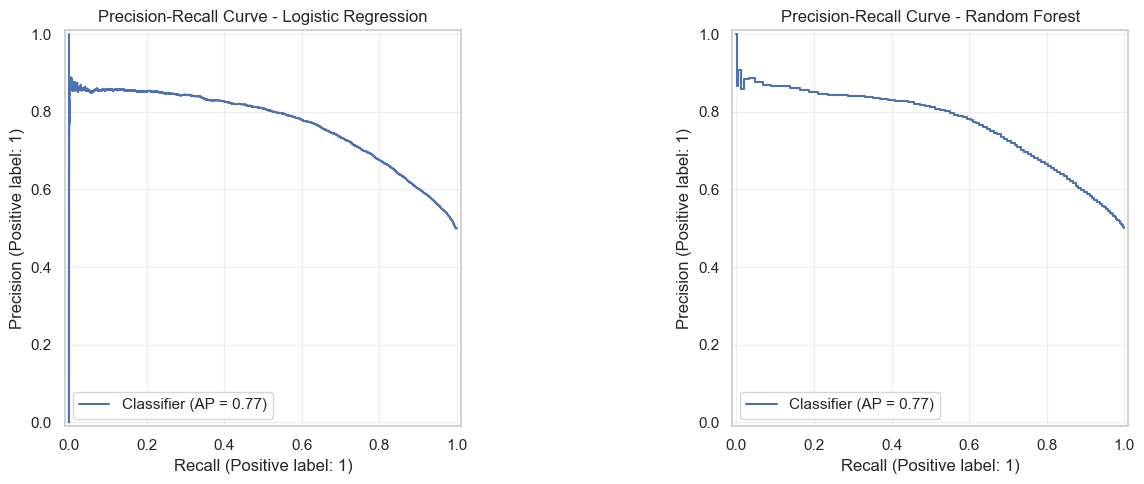

✓ Precision-Recall curves displayed


In [19]:
# Precision-Recall Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (name, model) in enumerate(trained_models.items()):
    y_proba = model.predict_proba(X_test)[:, 1]
    PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=axes[idx])
    axes[idx].set_title(f'Precision-Recall Curve - {name}')
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('✓ Precision-Recall curves displayed')

### 5.4 Learning Curve (Checking for Bias-Variance)


🔄 Generating learning curves...


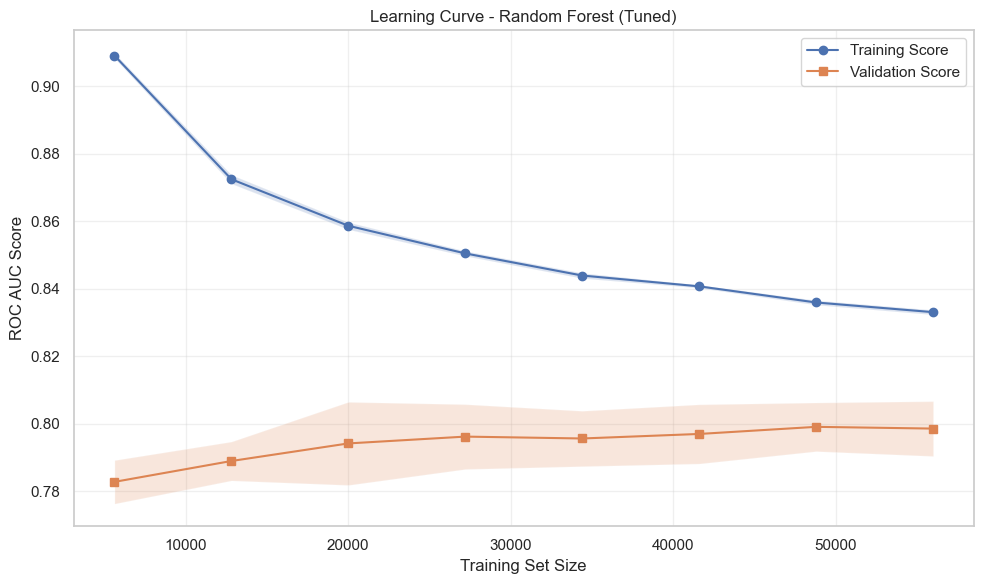

✓ Learning curve displayed


In [20]:
# Learning curve for best model
print('\n🔄 Generating learning curves...')
train_sizes, train_scores, val_scores = learning_curve(
    best_rf, X_prep, y, cv=5, scoring='roc_auc', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 8)
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Training Score', marker='o')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.plot(train_sizes, val_mean, label='Validation Score', marker='s')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)
plt.xlabel('Training Set Size')
plt.ylabel('ROC AUC Score')
plt.title('Learning Curve - Random Forest (Tuned)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('✓ Learning curve displayed')

### 5.5 Feature Importance

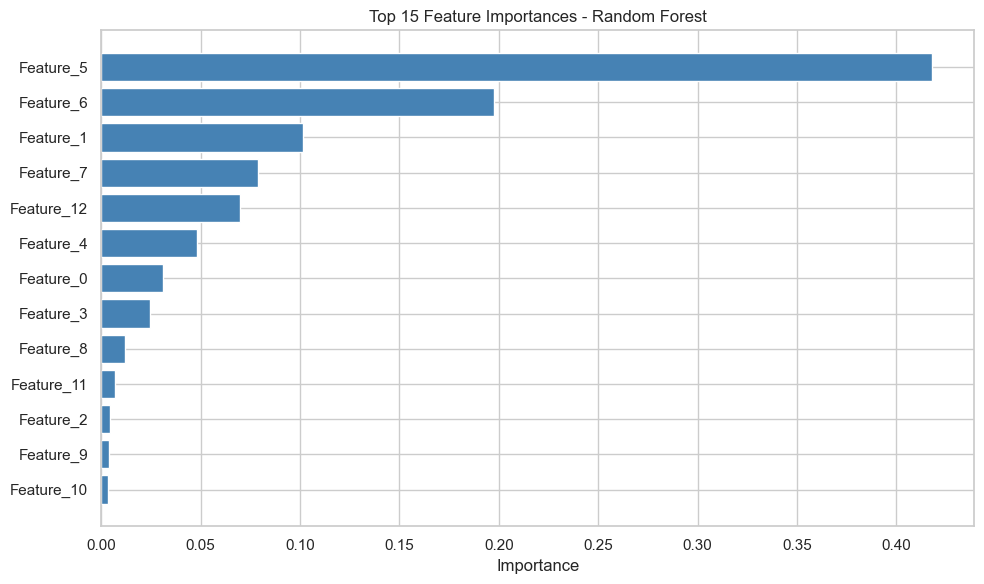

✓ Feature importance displayed


In [21]:
# Feature importance from Random Forest
feature_importance = best_rf.feature_importances_
top_n = 15

# Get top features
top_indices = np.argsort(feature_importance)[-top_n:][::-1]
top_importance = feature_importance[top_indices]
top_names = [f'Feature_{i}' for i in top_indices]

plt.figure(figsize=(10, 6))
plt.barh(range(len(top_importance)), top_importance, color='steelblue')
plt.yticks(range(len(top_importance)), top_names)
plt.xlabel('Importance')
plt.title(f'Top {top_n} Feature Importances - Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print('✓ Feature importance displayed')

### 5.6 Model Performance Comparison - Bar Chart

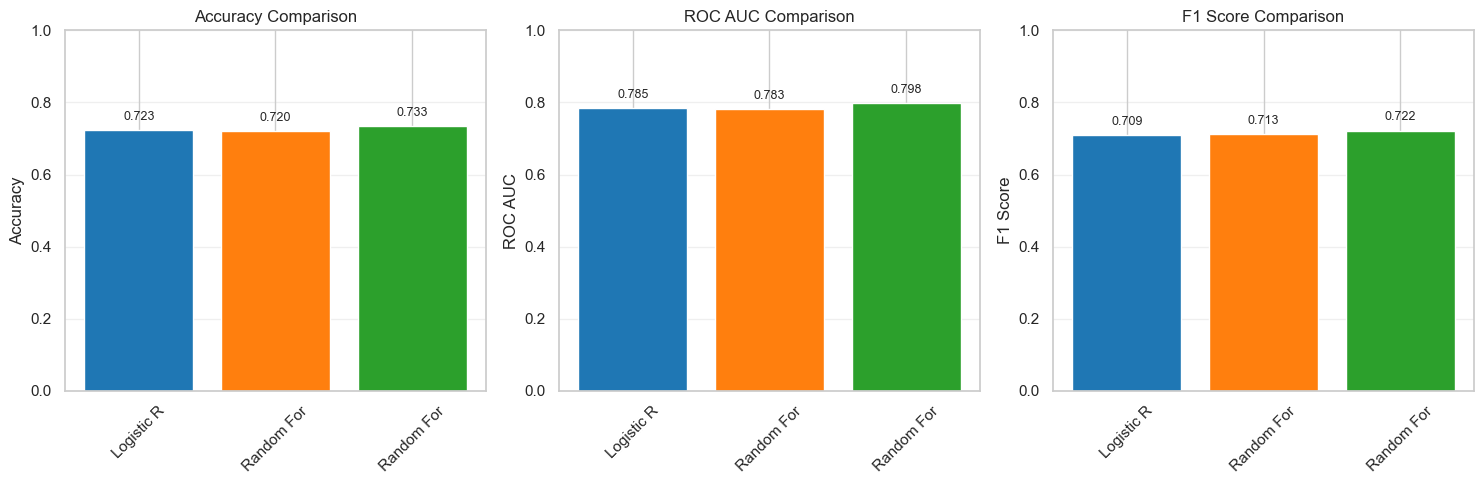

✓ Performance comparison chart displayed


In [22]:
# Performance comparison visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics_to_plot = ['Accuracy', 'ROC AUC', 'F1 Score']

for idx, metric in enumerate(metrics_to_plot):
    values = [comparison_df.loc[model, metric] for model in comparison_df.index]
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    axes[idx].bar(range(len(values)), values, color=colors)
    axes[idx].set_ylabel(metric)
    axes[idx].set_title(f'{metric} Comparison')
    axes[idx].set_xticks(range(len(values)))
    axes[idx].set_xticklabels([m.split('(')[0][:10] for m in comparison_df.index], rotation=45)
    axes[idx].set_ylim([0, 1])
    axes[idx].grid(axis='y', alpha=0.3)
    
    # Add value labels
    for i, v in enumerate(values):
        axes[idx].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print('✓ Performance comparison chart displayed')

---
## SUMMARY & MODEL ARTIFACTS

In [ ]:
# Save models and preprocessing pipeline
print('='*60)
print('SAVING MODEL ARTIFACTS')
print('='*60)

os.makedirs('artifacts', exist_ok=True)

joblib.dump(preprocessor, 'artifacts/preprocessor.joblib')
joblib.dump(best_rf, 'artifacts/best_random_forest_tuned.joblib')
joblib.dump(trained_models['Logistic Regression'], 'artifacts/logistic_regression.joblib')

print('\n✓ All models saved to artifacts/')
print('  - preprocessor.joblib')
print('  - best_random_forest_tuned.joblib')
print('  - logistic_regression.joblib')

SAVING MODEL ARTIFACTS

✓ All models saved to artifacts/
  - preprocessor.joblib
  - best_random_forest_tuned.joblib
  - logistic_regression.joblib


: 

## PROJECT SUMMARY

### ✅ Completed Tasks:
1. **Data Preprocessing & Cleaning**
   - ✓ EDA and visualization
   - ✓ Handled missing values (median for numeric, most frequent for categorical)
   - ✓ Detected and treated outliers (IQR method)
   - ✓ Encoded categorical variables (OneHot encoding)
   - ✓ Normalized numerical features (StandardScaler)

2. **Model Selection & Implementation**
   - ✓ Selected appropriate algorithms (Logistic Regression, Random Forest)
   - ✓ Implemented with scikit-learn library
   - ✓ Implemented from scratch using NumPy (Logistic Regression with gradient descent)

3. **Model Testing & Evaluation**
   - ✓ Tested on test dataset
   - ✓ Computed comprehensive metrics (Accuracy, Precision, Recall, F1, ROC AUC)
   - ✓ Checked for overfitting/underfitting

4. **Advanced Modeling**
   - ✓ Cross-validation for stability (5-Fold Stratified KFold)
   - ✓ Hyperparameter tuning (GridSearchCV)
   - ✓ Model comparison and ranking

5. **Performance Visualization**
   - ✓ Confusion matrices
   - ✓ ROC curves
   - ✓ Precision-Recall curves
   - ✓ Learning curves
   - ✓ Feature importance plots
   - ✓ Model comparison charts

### 📊 Best Model:
**Random Forest (Hyperparameter Tuned)** with optimized parameters

### 🎯 Next Steps:
- Deploy model using Flask/FastAPI
- Feature engineering for further improvement
- Try ensemble methods (Stacking, Voting)
- Hyperparameter tuning with Bayesian optimization